In [1]:
%pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
#Set seeds for reproducibility
import random
random.seed(0)
import numpy as np
np.random.seed(0)
import tensorflow as tf
tf.random.set_seed(0)

In [3]:
import os
import json
from zipfile import ZipFile
from PIL import Image

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

In [6]:
!pip install kaggle

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
kaggle_credentails = json.load(open("kaggle.json"))

In [5]:
# setup Kaggle API key as environment variables
os.environ['KAGGLE_USERNAME'] = kaggle_credentails["username"]
os.environ['KAGGLE_KEY'] = kaggle_credentails["key"]

In [ ]:
import kaggle
print(kaggle.__version__)

AttributeError: module 'kaggle' has no attribute '__version__'

In [7]:
!kaggle datasets download -d abdallahalidev/plantvillage-dataset

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0




  0%|          | 0.00/2.04G [00:00<?, ?B/s]
  0%|          | 1.00M/2.04G [00:01<47:01, 776kB/s]
  0%|          | 2.00M/2.04G [00:01<24:04, 1.51MB/s]
  0%|          | 3.00M/2.04G [00:01<15:12, 2.40MB/s]
  0%|          | 4.00M/2.04G [00:01<11:18, 3.22MB/s]
  0%|          | 7.00M/2.04G [00:02<05:11, 7.00MB/s]
  0%|          | 9.00M/2.04G [00:02<04:04, 8.90MB/s]
  1%|          | 11.0M/2.04G [00:02<03:59, 9.08MB/s]
  1%|          | 14.0M/2.04G [00:02<03:49, 9.49MB/s]
  1%|          | 18.0M/2.04G [00:02<02:37, 13.8MB/s]
  1%|          | 21.0M/2.04G [00:02<02:14, 16.1MB/s]
  1%|          | 23.0M/2.04G [00:03<02:27, 14.7MB/s]
  1%|          | 25.0M/2.04G [00:03<02:29, 14.5MB/s]
  1%|▏         | 27.0M/2.04G [00:03<02:36, 13.8MB/s]
  1%|▏         | 29.0M/2.04G [00:03<02:42, 13.3MB/s]
  1%|▏         | 31.0M/2.04G [00:03<02:43, 13.2MB/s]
  2%|▏         | 33.0M/2.04G [00:03<02:50, 12.6MB/s]
  2%|▏         | 35.0M/2.04G [00:04<02:52, 12.5MB/s]
  2%|▏         | 37.0M/2.04G [00:04<02:58, 12.0MB/s]
  

In [9]:
!ls

PlantDiseaseClassificationRecommendation.ipynb
kaggle.json
plantvillage-dataset.zip


In [10]:
# Unzip the downloaded dataset
with ZipFile("plantvillage-dataset.zip", 'r') as zip_ref:
    zip_ref.extractall()

In [11]:
print(os.listdir("plantvillage dataset"))


print(len(os.listdir("plantvillage dataset/segmented")))
print(os.listdir("plantvillage dataset/segmented")[:5])

print(len(os.listdir("plantvillage dataset/color")))
print(os.listdir("plantvillage dataset/color")[:5])

print(len(os.listdir("plantvillage dataset/grayscale")))
print(os.listdir("plantvillage dataset/grayscale")[:5])

['color', 'grayscale', 'segmented']
38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']
38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']
38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']


In [12]:
print(len(os.listdir("plantvillage dataset/color/Grape___healthy")))
print(os.listdir("plantvillage dataset/color/Grape___healthy")[:5])

423
['00e00912-bf75-4cf8-8b7d-ad64b73bea5f___Mt.N.V_HL 6067.JPG', '0163a6aa-fbf8-47c5-965f-59b6efe8bfe5___Mt.N.V_HL 6103.JPG', '0294ca65-4c29-44be-af28-501df9f715e8___Mt.N.V_HL 6176.JPG', '02f95acb-5d92-4f2a-b7ec-3af8709ee7c9___Mt.N.V_HL 9078.JPG', '03027791-26bb-4c46-960e-8df76e27042c___Mt.N.V_HL 6070.JPG']


Data Preprocessing

In [27]:
# Dataset Path
base_dir = 'plantvillage dataset/color'

(256, 256, 3)


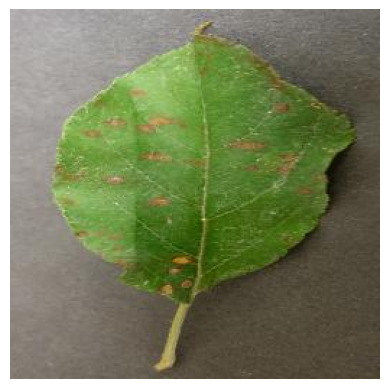

In [28]:
image_path = 'plantvillage dataset/color/Apple___Cedar_apple_rust/025b2b9a-0ec4-4132-96ac-7f2832d0db4a___FREC_C.Rust 3655.JPG'

# Read the image
img = mpimg.imread(image_path)

print(img.shape)
# Display the image
plt.imshow(img)
plt.axis('off')  # Turn off axis numbers
plt.show()

In [29]:
image_path = 'plantvillage dataset/color/Apple___Cedar_apple_rust/025b2b9a-0ec4-4132-96ac-7f2832d0db4a___FREC_C.Rust 3655.JPG'

# Read the image
img = mpimg.imread(image_path)

print(img)

[[[179 175 176]
  [181 177 178]
  [184 180 181]
  ...
  [115 112 105]
  [108 105  98]
  [101  98  91]]

 [[176 172 173]
  [177 173 174]
  [178 174 175]
  ...
  [113 110 103]
  [111 108 101]
  [109 106  99]]

 [[180 176 177]
  [180 176 177]
  [180 176 177]
  ...
  [108 105  98]
  [111 108 101]
  [114 111 104]]

 ...

 [[137 128 119]
  [131 122 113]
  [125 116 107]
  ...
  [ 74  65  48]
  [ 74  65  48]
  [ 73  64  47]]

 [[136 127 118]
  [132 123 114]
  [128 119 110]
  ...
  [ 77  69  50]
  [ 75  67  48]
  [ 75  67  48]]

 [[133 124 115]
  [133 124 115]
  [132 123 114]
  ...
  [ 81  73  54]
  [ 80  72  53]
  [ 79  71  52]]]


In [30]:
# Image Parameters
img_size = 224
batch_size = 32

1. Convolutional Neural Network (CNN)

In [31]:
# Image Data Generators (for CNN)
data_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2  # Use 20% of data for validation
)

In [32]:
# Train Generator (for CNN)
train_generator = data_gen.flow_from_directory(
    base_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    subset='training',
    class_mode='categorical'
)

Found 43456 images belonging to 38 classes.


In [33]:
# Validation Generator (for CNN)
validation_generator = data_gen.flow_from_directory(
    base_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    subset='validation',
    class_mode='categorical'
)

Found 10849 images belonging to 38 classes.


In [34]:
# CNN Model Definition
model = models.Sequential()

model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(img_size, img_size, 3)))
model.add(layers.MaxPooling2D(2, 2))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D(2, 2))


model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dense(train_generator.num_classes, activation='softmax'))

C:\Users\dhruv\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [35]:
# CNN model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    47,776,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,805,158 (182.36 MB)

 Trainable params: 47,805,158 (182.36 MB)

 Non-trainable params: 0 (0.00 B)

In [36]:
# Compile the CNN Model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
# Training the CNN Model
history_cnn = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,  # Number of steps per epoch
    epochs=5,  # Number of epochs
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size  # Validation steps
)

In [ ]:
# CNN Model Evaluation
print("Evaluating CNN model...")
val_loss, val_accuracy = model.evaluate(validation_generator, steps=validation_generator.samples // batch_size)
print(f"CNN Validation Accuracy: {val_accuracy * 100:.2f}%")

Evaluating CNN model...
339/339 ━━━━━━━━━━━━━━━━━━━━ 15s 43ms/step - accuracy: 0.8649 - loss: 0.5999
CNN Validation Accuracy: 86.68%


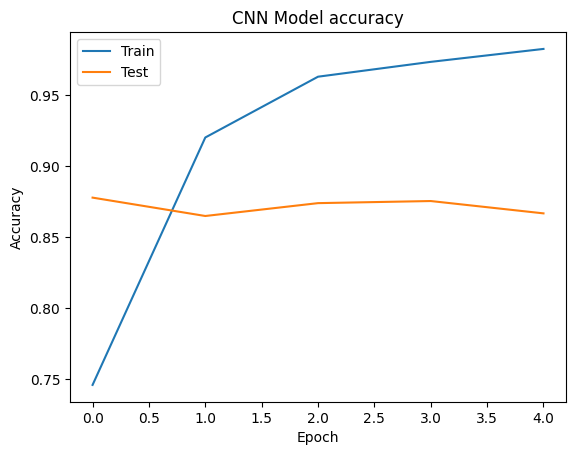

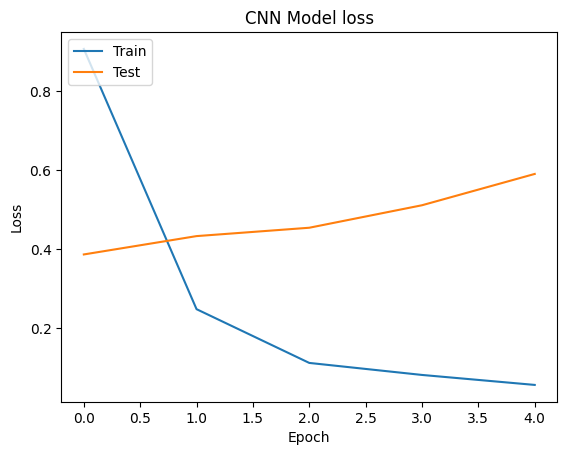

In [ ]:
# Plot training & validation accuracy values for CNN
plt.plot(history_cnn.history['accuracy'])
plt.plot(history_cnn.history['val_accuracy'])
plt.title('CNN Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# Plot training & validation loss values for CNN
plt.plot(history_cnn.history['loss'])
plt.plot(history_cnn.history['val_loss'])
plt.title('CNN Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

In [ ]:
# Create a mapping from class indices to class names
class_indices = {v: k for k, v in train_generator.class_indices.items()}

In [ ]:
# Function to Load and Preprocess the Image using Pillow (for CNN model)
def load_and_preprocess_image_cnn(image_path, target_size=(224, 224)):
    # Load the image
    img = Image.open(image_path)
    # Resize the image
    img = img.resize(target_size)
    # Convert the image to a numpy array
    img_array = np.array(img)
    # Add batch dimension
    img_array = np.expand_dims(img_array, axis=0)
    # Scale the image values to [0, 1]
    img_array = img_array.astype('float32') / 255.
    return img_array

# Function to Predict the Class of an Image (for CNN model)
def predict_image_class_cnn(model, image_path, class_indices):
    preprocessed_img = load_and_preprocess_image_cnn(image_path)
    predictions = model.predict(preprocessed_img)
    predicted_class_index = np.argmax(predictions, axis=1)[0]
    predicted_class_name = class_indices[predicted_class_index]
    return predicted_class_name

In [ ]:
class_indices

{0: 'Apple___Apple_scab',
 1: 'Apple___Black_rot',
 2: 'Apple___Cedar_apple_rust',
 3: 'Apple___healthy',
 4: 'Blueberry___healthy',
 5: 'Cherry_(including_sour)___Powdery_mildew',
 6: 'Cherry_(including_sour)___healthy',
 7: 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 8: 'Corn_(maize)___Common_rust_',
 9: 'Corn_(maize)___Northern_Leaf_Blight',
 10: 'Corn_(maize)___healthy',
 11: 'Grape___Black_rot',
 12: 'Grape___Esca_(Black_Measles)',
 13: 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 14: 'Grape___healthy',
 15: 'Orange___Haunglongbing_(Citrus_greening)',
 16: 'Peach___Bacterial_spot',
 17: 'Peach___healthy',
 18: 'Pepper,_bell___Bacterial_spot',
 19: 'Pepper,_bell___healthy',
 20: 'Potato___Early_blight',
 21: 'Potato___Late_blight',
 22: 'Potato___healthy',
 23: 'Raspberry___healthy',
 24: 'Soybean___healthy',
 25: 'Squash___Powdery_mildew',
 26: 'Strawberry___Leaf_scorch',
 27: 'Strawberry___healthy',
 28: 'Tomato___Bacterial_spot',
 29: 'Tomato___Early_blight',
 30: '

In [ ]:
# saving the class names as json file
json.dump(class_indices, open('class_indices.json', 'w'))

In [ ]:
# Example Usage for CNN
#image_path_cnn = '/content/Img2.JPG'
image_path_cnn = '/content/test_apple_black_rot.jpg'
#image_path_cnn = '/content/test_potato_early_blight.jpg'
predicted_class_name_cnn = predict_image_class_cnn(model, image_path_cnn, class_indices)

# Output the result
print("Predicted Class Name (CNN):", predicted_class_name_cnn)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 916ms/step
Predicted Class Name (CNN): Apple___Black_rot


In [ ]:
model.save('plant_disease_prediction_model_cnn.h5')

2. VGG16 Model (Transfer Learning)

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.models import Model
from tensorflow.keras import optimizers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import math

In [ ]:
# VGG16 Data Generators
# We use the same base_dir but with the VGG16-specific preprocessing function
gen_base_vgg = ImageDataGenerator(
    preprocessing_function=vgg_preprocess, # Use VGG16's preprocess_input
    validation_split=0.2
)

# VGG Train Generator
train_gen_vgg = gen_base_vgg.flow_from_directory(
    base_dir, # Using the 'color' dataset directory
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# VGG Validation Generator
val_gen_vgg = gen_base_vgg.flow_from_directory(
    base_dir, # Using the 'color' dataset directory
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# Compute steps
steps_per_epoch_vgg = math.ceil(train_gen_vgg.samples / batch_size)
val_steps_vgg = math.ceil(val_gen_vgg.samples / batch_size)

Found 43456 images belonging to 38 classes.
Found 10849 images belonging to 38 classes.


In [ ]:
# VGG16 Model Builder Function
def build_vgg16_model(input_shape=(224, 224, 3), n_classes=38):
    base = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    base.trainable = False  # Freeze the base model

    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(n_classes, activation='softmax')(x)

    model = models.Model(inputs=base.input, outputs=outputs, name="VGG16_transfer")

    model.compile(optimizer=optimizers.Adam(1e-3),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [ ]:
# Callbacks for VGG16
checkpoint_vgg = ModelCheckpoint("best_vgg16_model.h5",
                                 monitor='val_accuracy',
                                 save_best_only=True,
                                 mode='max',
                                 verbose=1)

earlystop = EarlyStopping(monitor='val_loss',
                          patience=5,
                          restore_best_weights=True,
                          verbose=1)

reduce_lr = ReduceLROnPlateau(monitor='val_loss',
                              factor=0.5,
                              patience=3,
                              verbose=1)

In [ ]:
# Build and Summarize VGG16 model
n_classes_vgg = train_gen_vgg.num_classes
vgg_model = build_vgg16_model(input_shape=(img_size, img_size, 3), n_classes=n_classes_vgg)
vgg_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "VGG16_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 38)             │        19,494 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,996,838 (57.21 MB)

 Trainable params: 282,150 (1.08 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
# Train the VGG16 Model
print("Training VGG16 model...")
history_vgg = vgg_model.fit(
    train_gen_vgg,
    steps_per_epoch=steps_per_epoch_vgg,
    validation_data=val_gen_vgg,
    validation_steps=val_steps_vgg,
    epochs=5,  # Same number of epochs as the CNN
    callbacks=[checkpoint_vgg, earlystop, reduce_lr],
    verbose=1
)

Training VGG16 model...
Epoch 1/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.7110 - loss: 1.2373
Epoch 1: val_accuracy improved from -inf to 0.94202, saving model to best_vgg16_model.h5


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 302s 212ms/step - accuracy: 0.7111 - loss: 1.2369 - val_accuracy: 0.9420 - val_loss: 0.1792 - learning_rate: 0.0010
Epoch 2/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.9078 - loss: 0.2842
Epoch 2: val_accuracy improved from 0.94202 to 0.94635, saving model to best_vgg16_model.h5


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 290s 213ms/step - accuracy: 0.9078 - loss: 0.2842 - val_accuracy: 0.9464 - val_loss: 0.1635 - learning_rate: 0.0010
Epoch 3/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.9215 - loss: 0.2413
Epoch 3: val_accuracy improved from 0.94635 to 0.95585, saving model to best_vgg16_model.h5


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 319s 211ms/step - accuracy: 0.9215 - loss: 0.2413 - val_accuracy: 0.9558 - val_loss: 0.1354 - learning_rate: 0.0010
Epoch 4/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.9328 - loss: 0.2045
Epoch 4: val_accuracy improved from 0.95585 to 0.95963, saving model to best_vgg16_model.h5


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 289s 213ms/step - accuracy: 0.9328 - loss: 0.2045 - val_accuracy: 0.9596 - val_loss: 0.1197 - learning_rate: 0.0010
Epoch 5/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.9375 - loss: 0.1949
Epoch 5: val_accuracy improved from 0.95963 to 0.96027, saving model to best_vgg16_model.h5


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 288s 212ms/step - accuracy: 0.9375 - loss: 0.1949 - val_accuracy: 0.9603 - val_loss: 0.1179 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 5.


In [ ]:
# VGG16 Model Evaluation
print("Evaluating VGG16 model...")
val_loss_vgg, val_accuracy_vgg = vgg_model.evaluate(val_gen_vgg, steps=val_steps_vgg)
print(f"VGG16 Validation Accuracy: {val_accuracy_vgg * 100:.2f}%")

Evaluating VGG16 model...
340/340 ━━━━━━━━━━━━━━━━━━━━ 60s 175ms/step - accuracy: 0.9649 - loss: 0.1075
VGG16 Validation Accuracy: 96.03%


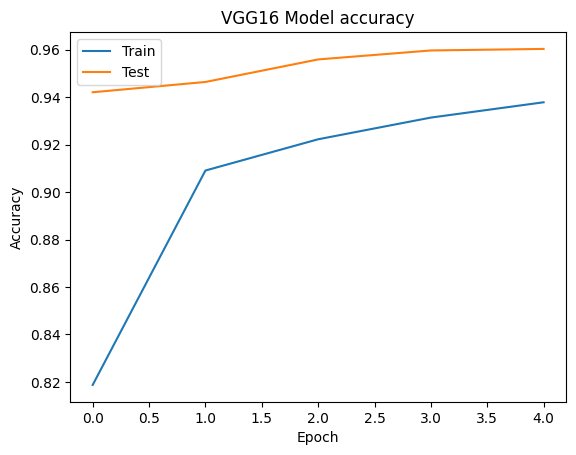

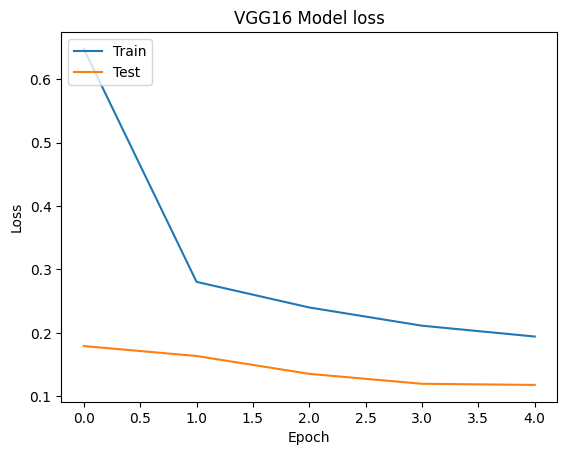

In [ ]:
# Plot training & validation accuracy values for VGG16
plt.plot(history_vgg.history['accuracy'])
plt.plot(history_vgg.history['val_accuracy'])
plt.title('VGG16 Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# Plot training & validation loss values for VGG16
plt.plot(history_vgg.history['loss'])
plt.plot(history_vgg.history['val_loss'])
plt.title('VGG16 Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

In [ ]:
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess

def load_and_preprocess_image_vgg(image_path, target_size=(224, 224)):
    img = Image.open(image_path)
    img = img.resize(target_size)
    img_array = np.array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = vgg_preprocess(img_array)
    return img_array

def predict_image_class_vgg(model, image_path, class_indices):
    preprocessed_img = load_and_preprocess_image_vgg(image_path)
    predictions = model.predict(preprocessed_img)
    predicted_class_index = np.argmax(predictions, axis=1)[0]
    predicted_class_name = class_indices[predicted_class_index]
    return predicted_class_name

In [ ]:
class_indices_vgg = {v: k for k, v in train_gen_vgg.class_indices.items()}

In [ ]:
# Example Usage for VGG
image_path_vgg = '/content/test_apple_black_rot.jpg'

predicted_class_name_vgg = predict_image_class_vgg(vgg_model, image_path_vgg, class_indices_vgg)

print("Predicted Class Name (VGG16):", predicted_class_name_vgg)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 649ms/step
Predicted Class Name (VGG16): Apple___Black_rot


In [ ]:
vgg_model.save('plant_disease_prediction_model_vgg16.h5')

ResNet50 Model (Transfer Learning)

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

In [ ]:
# ResNet50 Data Generators
gen_base_resnet = ImageDataGenerator(
    preprocessing_function=resnet_preprocess, # Use ResNet50's preprocess_input
    validation_split=0.2
)

# ResNet Train Generator
train_gen_resnet = gen_base_resnet.flow_from_directory(
    base_dir, # Using the 'color' dataset directory
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# ResNet Validation Generator
val_gen_resnet = gen_base_resnet.flow_from_directory(
    base_dir, # Using the 'color' dataset directory
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# Compute steps
steps_per_epoch_resnet = math.ceil(train_gen_resnet.samples / batch_size)
val_steps_resnet = math.ceil(val_gen_resnet.samples / batch_size)

Found 43456 images belonging to 38 classes.
Found 10849 images belonging to 38 classes.


In [ ]:
# ResNet50 Model Builder Function
def build_resnet50_model(input_shape=(224, 224, 3), n_classes=38):
    base = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    base.trainable = False  # Freeze the base model

    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(n_classes, activation='softmax')(x)

    model = models.Model(inputs=base.input, outputs=outputs, name="ResNet50_transfer")

    model.compile(optimizer=optimizers.Adam(1e-3),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [ ]:
# Callbacks for ResNet50
checkpoint_resnet = ModelCheckpoint("best_resnet50_model.h5",
                                    monitor='val_accuracy',
                                    save_best_only=True,
                                    mode='max',
                                    verbose=1)
# we can re-use the 'earlystop' and 'reduce_lr' callbacks from the VGG section

In [ ]:
# Build and Summarize ResNet50 model
n_classes_resnet = train_gen_resnet.num_classes
resnet_model = build_resnet50_model(input_shape=(img_size, img_size, 3), n_classes=n_classes_resnet)
resnet_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "ResNet50_transfer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,656,294 (94.06 MB)

 Trainable params: 1,068,582 (4.08 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
# Train the ResNet50 Model
print("Training ResNet50 model...")
history_resnet = resnet_model.fit(
    train_gen_resnet,
    steps_per_epoch=steps_per_epoch_resnet,
    validation_data=val_gen_resnet,
    validation_steps=val_steps_resnet,
    epochs=5,  # Same number of epochs as the other models
    callbacks=[checkpoint_resnet, earlystop, reduce_lr],
    verbose=1
)

Training ResNet50 model...
Epoch 1/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.7962 - loss: 0.7499
Epoch 1: val_accuracy improved from -inf to 0.95511, saving model to best_resnet50_model.h5


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 167s 114ms/step - accuracy: 0.7963 - loss: 0.7496 - val_accuracy: 0.9551 - val_loss: 0.1330 - learning_rate: 0.0010
Epoch 2/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.9353 - loss: 0.1933
Epoch 2: val_accuracy improved from 0.95511 to 0.96580, saving model to best_resnet50_model.h5


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 148s 109ms/step - accuracy: 0.9353 - loss: 0.1933 - val_accuracy: 0.9658 - val_loss: 0.1014 - learning_rate: 0.0010
Epoch 3/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.9493 - loss: 0.1563
Epoch 3: val_accuracy improved from 0.96580 to 0.97216, saving model to best_resnet50_model.h5


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 148s 109ms/step - accuracy: 0.9493 - loss: 0.1563 - val_accuracy: 0.9722 - val_loss: 0.0817 - learning_rate: 0.0010
Epoch 4/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.9550 - loss: 0.1361
Epoch 4: val_accuracy improved from 0.97216 to 0.97788, saving model to best_resnet50_model.h5


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 148s 109ms/step - accuracy: 0.9550 - loss: 0.1361 - val_accuracy: 0.9779 - val_loss: 0.0669 - learning_rate: 0.0010
Epoch 5/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.9573 - loss: 0.1311
Epoch 5: val_accuracy did not improve from 0.97788
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 202s 109ms/step - accuracy: 0.9573 - loss: 0.1311 - val_accuracy: 0.9732 - val_loss: 0.0855 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 4.


In [ ]:
# ResNet50 Model Evaluation
print("Evaluating ResNet50 model...")
val_loss_resnet, val_accuracy_resnet = resnet_model.evaluate(val_gen_resnet, steps=val_steps_resnet)
print(f"ResNet50 Validation Accuracy: {val_accuracy_resnet * 100:.2f}%")

Evaluating ResNet50 model...
340/340 ━━━━━━━━━━━━━━━━━━━━ 30s 89ms/step - accuracy: 0.9802 - loss: 0.0632
ResNet50 Validation Accuracy: 97.79%


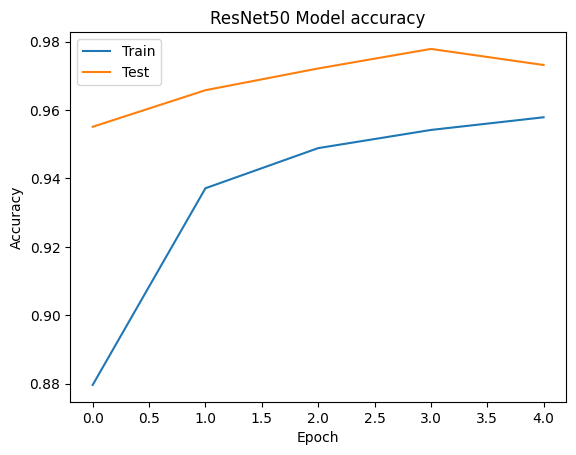

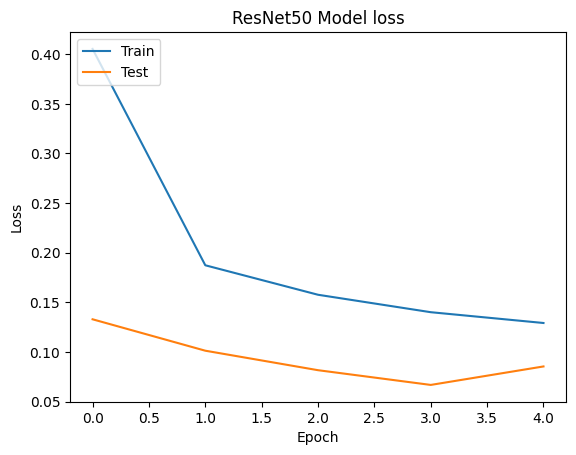

In [ ]:
# Plot training & validation accuracy values for ResNet50
plt.plot(history_resnet.history['accuracy'])
plt.plot(history_resnet.history['val_accuracy'])
plt.title('ResNet50 Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# Plot training & validation loss values for ResNet50
plt.plot(history_resnet.history['loss'])
plt.plot(history_resnet.history['val_loss'])
plt.title('ResNet50 Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

In [ ]:
# --- Functions for ResNet50 Prediction ---
def load_and_preprocess_image_resnet(image_path, target_size=(224, 224)):
    img = Image.open(image_path)
    img = img.resize(target_size)
    img_array = np.array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = resnet_preprocess(img_array) # Use ResNet's specific preprocessing
    return img_array

def predict_image_class_resnet(model, image_path, class_indices):
    preprocessed_img = load_and_preprocess_image_resnet(image_path)
    predictions = model.predict(preprocessed_img)
    predicted_class_index = np.argmax(predictions, axis=1)[0]
    predicted_class_name = class_indices[predicted_class_index]
    return predicted_class_name

In [ ]:
# --- Example Usage for ResNet50 ---
class_indices_resnet = {v: k for k, v in train_gen_resnet.class_indices.items()}

In [ ]:
# Testing the model on an example image
image_path_resnet = '/content/test_apple_black_rot.jpg'

predicted_class_name_resnet = predict_image_class_resnet(resnet_model, image_path_resnet, class_indices_resnet)

print("Predicted Class Name (ResNet50):", predicted_class_name_resnet)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Predicted Class Name (ResNet50): Apple___Black_rot


In [ ]:
resnet_model.save('plant_disease_prediction_model_resnet50.h5')

In [ ]:
import google.generativeai as genai
import numpy as np
from PIL import Image
from google.colab import userdata
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

# 1. CONFIGURE THE API KEY 
try:
    GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')
    genai.configure(api_key=GOOGLE_API_KEY)
    print("SUCCESS: API Key found and configured.")

    # # List available models (fixed version)
    # print("\nListing available models:")
    # for m in genai.list_models():
    #     if 'generateContent' in m.supported_generation_methods:
    #         print(f"  - {m.name}")

except Exception as e:
    print(f"ERROR: Could not find API Key. Error: {e}")
    GOOGLE_API_KEY = None


# 2. Functions for ResNet50 Prediction 
def load_and_preprocess_image_resnet(image_path, target_size=(224, 224)):
    img = Image.open(image_path)
    img = img.resize(target_size)
    img_array = np.array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = resnet_preprocess(img_array)
    return img_array

def predict_image_class_resnet(model, image_path, class_indices):
    preprocessed_img = load_and_preprocess_image_resnet(image_path)
    predictions = model.predict(preprocessed_img, verbose=0)
    predicted_class_index = np.argmax(predictions, axis=1)[0]
    predicted_class_name = class_indices[predicted_class_index]
    return predicted_class_name


#  3. Function for LLM Treatment Recommendation (UPDATED MODEL) 
def get_treatment_recommendation(disease_name):
    if not GOOGLE_API_KEY:
        return "Error: GOOGLE_API_KEY is not set. Please get a key from Google AI Studio and add it to your environment."

    try:
        # Using gemini-2.5-flash (current available model)
        model = genai.GenerativeModel('gemini-2.5-flash')

        prompt = f"""
        You are an expert plant pathologist.
        Provide a brief treatment recommendation for the plant disease: '{disease_name}'.

        Focus on practical steps a home gardener or small farmer could take.
        Include both cultural/mechanical (e.g., pruning, sanitation) and potential chemical (e.g., fungicide) advice if applicable.
        Keep the entire response under 80 words.

        Disease: {disease_name}
        Recommendation:
        """

        response = model.generate_content(prompt)
        return response.text

    except Exception as e:
        return f"Error generating recommendation: {e}"


# 4. RUN PREDICTION AND GET RECOMMENDATION

# Get class indices from the ResNet generator
class_indices_resnet = {v: k for k, v in train_gen_resnet.class_indices.items()}

# Define the path to your test image
image_path_to_test = '/content/test_apple_black_rot.jpg'

print(f"Processing image: {image_path_to_test}...")

# Predict using the best model (ResNet50)
predicted_disease = predict_image_class_resnet(resnet_model, image_path_to_test, class_indices_resnet)

print(f"\n DIAGNOSIS: {predicted_disease}")
print("-" * 30)

# Get LLM Advice
if "healthy" in predicted_disease.lower():
    print("The plant is healthy! No treatment needed. Keep monitoring.")
else:
    print(" GENERATING TREATMENT PLAN...")
    advice = get_treatment_recommendation(predicted_disease)
    print(advice)

In [ ]:
import gradio as gr
import google.generativeai as genai
import numpy as np
from PIL import Image
from google.colab import userdata
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

# Your existing setup code here...
GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')
genai.configure(api_key=GOOGLE_API_KEY)

# Your existing functions...
def load_and_preprocess_image_resnet(image_path, target_size=(224, 224)):
    img = Image.open(image_path)
    img = img.resize(target_size)
    img_array = np.array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = resnet_preprocess(img_array)
    return img_array

def predict_image_class_resnet(model, image_path, class_indices):
    preprocessed_img = load_and_preprocess_image_resnet(image_path)
    predictions = model.predict(preprocessed_img, verbose=0)
    predicted_class_index = np.argmax(predictions, axis=1)[0]
    predicted_class_name = class_indices[predicted_class_index]
    return predicted_class_name

def get_treatment_recommendation(disease_name):
    if not GOOGLE_API_KEY:
        return "Error: GOOGLE_API_KEY is not set."

    try:
        model = genai.GenerativeModel('gemini-2.5-flash')

        prompt = f"""
        You are an expert plant pathologist.
        Provide a brief treatment recommendation for the plant disease: '{disease_name}'.

        Focus on practical steps a home gardener or small farmer could take.
        Include both cultural/mechanical (e.g., pruning, sanitation) and potential chemical (e.g., fungicide) advice if applicable.
        Keep the entire response under 80 words.

        Disease: {disease_name}
        Recommendation:
        """

        response = model.generate_content(prompt)
        return response.text

    except Exception as e:
        return f"Error generating recommendation: {e}"

# Main prediction function for Gradio
def predict_and_recommend(image):
    try:
        # Save the uploaded image temporarily
        temp_path = '/content/temp_image.jpg'
        image.save(temp_path)

        # Get class indices
        class_indices_resnet = {v: k for k, v in train_gen_resnet.class_indices.items()}

        # Predict disease
        predicted_disease = predict_image_class_resnet(resnet_model, temp_path, class_indices_resnet)

        # Format disease name
        disease_display = predicted_disease.replace("___", " - ").replace("_", " ")

        # Check if healthy
        if "healthy" in predicted_disease.lower():
            diagnosis = f" **Diagnosis:** {disease_display}"
            treatment = " The plant is healthy! No treatment needed. Keep monitoring and maintain good plant care practices."
        else:
            diagnosis = f" **Diagnosis:** {disease_display}"
            treatment = f" **Treatment Recommendation:**\n\n{get_treatment_recommendation(predicted_disease)}"

        return diagnosis, treatment

    except Exception as e:
        return f"Error: {str(e)}", ""

# Create Gradio interface
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown(
        """
        #  Plant Disease Detector
        Upload an image of a plant leaf to diagnose diseases and get treatment recommendations
        """
    )

    with gr.Row():
        with gr.Column():
            image_input = gr.Image(type="pil", label="Upload Plant Image")
            predict_btn = gr.Button(" Analyze Plant", variant="primary", size="lg")

        with gr.Column():
            diagnosis_output = gr.Markdown(label="Diagnosis")
            treatment_output = gr.Markdown(label="Treatment")

    predict_btn.click(
        fn=predict_and_recommend,
        inputs=image_input,
        outputs=[diagnosis_output, treatment_output]
    )

    gr.Examples(
        examples=["/content/test_apple_black_rot.jpg"],  # Add your example images
        inputs=image_input
    )

# Launch the interface
demo.launch(share=True, debug=True)

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from IPython.display import display

In [ ]:
# Define common parameters from notebook 
img_size = 224
batch_size = 32
base_dir = 'plantvillage dataset/color'

# 1. CNN (Custom) 
print("Preparing CNN data (using new non-shuffled generator)...")
data_gen_cnn = ImageDataGenerator(rescale=1./255, validation_split=0.2)
eval_generator_cnn = data_gen_cnn.flow_from_directory(
    base_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    subset='validation',
    class_mode='categorical',
    shuffle=False  # IMPORTANT
)

# Get class labels and count 
class_labels = list(eval_generator_cnn.class_indices.keys())
num_classes = len(class_labels)
print(f"Found {num_classes} classes.")

# Continue getting CNN predictions
Y_pred_cnn = model.predict(eval_generator_cnn, steps=math.ceil(eval_generator_cnn.samples / batch_size))
y_pred_cnn = np.argmax(Y_pred_cnn, axis=1)
y_true_cnn = eval_generator_cnn.classes
y_true_cnn_oh = to_categorical(y_true_cnn, num_classes=num_classes)

# 2. VGG16
print("Preparing VGG16 data...")
val_gen_vgg.reset() # Reset generator to start from the beginning
Y_pred_vgg = vgg_model.predict(val_gen_vgg, steps=math.ceil(val_gen_vgg.samples / batch_size))
y_pred_vgg = np.argmax(Y_pred_vgg, axis=1)
y_true_vgg = val_gen_vgg.classes
y_true_vgg_oh = to_categorical(y_true_vgg, num_classes=num_classes)

# 3. ResNet50 
print("Preparing ResNet50 data...")
val_gen_resnet.reset()
Y_pred_resnet = resnet_model.predict(val_gen_resnet, steps=math.ceil(val_gen_resnet.samples / batch_size))
y_pred_resnet = np.argmax(Y_pred_resnet, axis=1)
y_true_resnet = val_gen_resnet.classes
y_true_resnet_oh = to_categorical(y_true_resnet, num_classes=num_classes)

print("\nAll predictions and labels are ready.")

Preparing CNN data (using new non-shuffled generator)...
Found 10849 images belonging to 38 classes.
Found 38 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


340/340 ━━━━━━━━━━━━━━━━━━━━ 15s 43ms/step
Preparing VGG16 data...
340/340 ━━━━━━━━━━━━━━━━━━━━ 60s 176ms/step
Preparing ResNet50 data...
340/340 ━━━━━━━━━━━━━━━━━━━━ 37s 99ms/step

All predictions and labels are ready.


In [ ]:
# Function to gather all metrics into a dictionary 
def get_model_metrics(model_name, y_true, y_pred_probs, num_classes):
    # Get class-level predictions (0, 1, 2, ...)
    y_pred_classes = np.argmax(y_pred_probs, axis=1)

    # Get one-hot encoded true labels for AUC
    y_true_one_hot = to_categorical(y_true, num_classes=num_classes)

    # 1. Accuracy
    accuracy = accuracy_score(y_true, y_pred_classes)

    # 2. Precision (Weighted)
    precision = precision_score(y_true, y_pred_classes, average='weighted', zero_division=0)

    # 3. Recall (Weighted)
    recall = recall_score(y_true, y_pred_classes, average='weighted', zero_division=0)

    # 4. F1-Score (Weighted)
    f1 = f1_score(y_true, y_pred_classes, average='weighted', zero_division=0)

    # 6. AUC-ROC Score (Weighted One-vs-Rest)
    # We use the prediction probabilities (y_pred_probs) for this
    auc_score = roc_auc_score(y_true_one_hot, y_pred_probs, average='weighted', multi_class='ovr')

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision (Weighted)": precision,
        "Recall (Weighted)": recall,
        "F1-Score (Weighted)": f1,
        "AUC (Weighted OvR)": auc_score
    }

# --- Collect all results ---
results_list = []
results_list.append(get_model_metrics("CNN (Custom)", y_true_cnn, Y_pred_cnn, num_classes))
results_list.append(get_model_metrics("VGG16", y_true_vgg, Y_pred_vgg, num_classes))
results_list.append(get_model_metrics("ResNet50", y_true_resnet, Y_pred_resnet, num_classes))
# InceptionV3 and MobileNetV2 are skipped as requested

# --- Create and Display the DataFrame ---
results_df = pd.DataFrame(results_list)
results_df = results_df.set_index("Model")

print("--- Combined Model Metrics Table ---")
# The 'display()' function will print the table in a nice format in your notebook
display(results_df.style.format("{:.4f}"))

--- Combined Model Metrics Table ---


,Accuracy,Precision (Weighted),Recall (Weighted),F1-Score (Weighted),AUC (Weighted OvR)
Model,,,,,
CNN (Custom),0.8667,0.8725,0.8667,0.8638,0.9961
VGG16,0.9603,0.9619,0.9603,0.9602,0.9996
ResNet50,0.9779,0.9784,0.9779,0.9778,0.9999


--- ResNet50 Plots ---


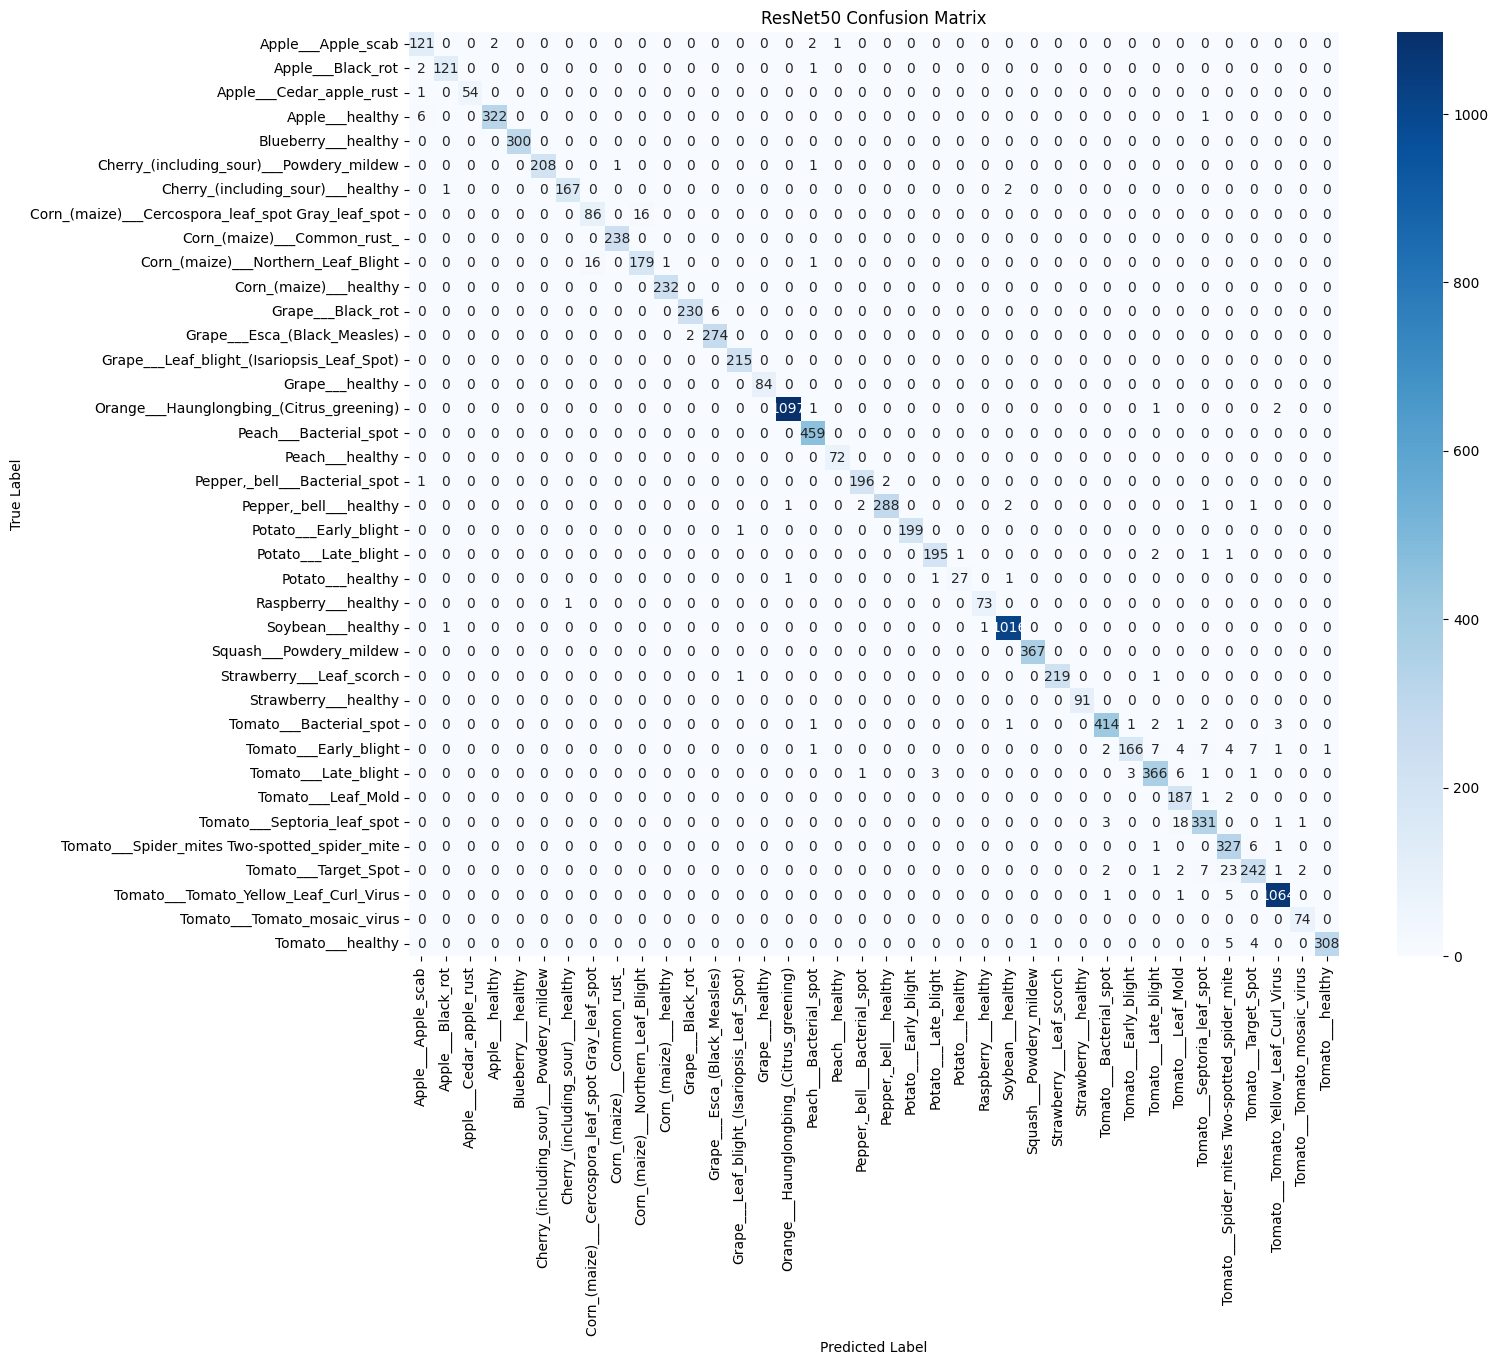

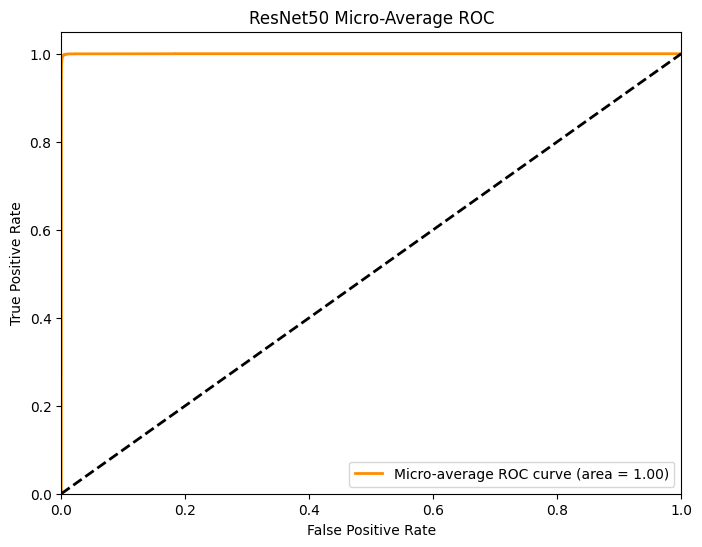

In [ ]:
# Helper function to plot Confusion Matrix 
def plot_confusion_matrix(cm, class_names, title='Confusion Matrix'):
    plt.figure(figsize=(15, 12))
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

# Helper function to plot AUC-ROC Curve (Micro-average) 
def plot_roc_curve(y_true_one_hot, y_pred_probs, title='ROC Curve'):
    # Calculate micro-average ROC curve and ROC area
    fpr, tpr, _ = roc_curve(y_true_one_hot.ravel(), y_pred_probs.ravel())
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2,
             label=f'Micro-average ROC curve (area = {roc_auc:0.2f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc="lower right")
    plt.show()

# Example: Plotting for the ResNet50 model (the best one) 
print("--- ResNet50 Plots ---")
cm_resnet = confusion_matrix(y_true_resnet, y_pred_resnet)
plot_confusion_matrix(cm_resnet, class_labels, title='ResNet50 Confusion Matrix')
plot_roc_curve(y_true_resnet_oh, Y_pred_resnet, title='ResNet50 Micro-Average ROC')

--- Generating CNN (Custom) Plots ---
Saved confusion matrix to: cnn_confusion_matrix.png


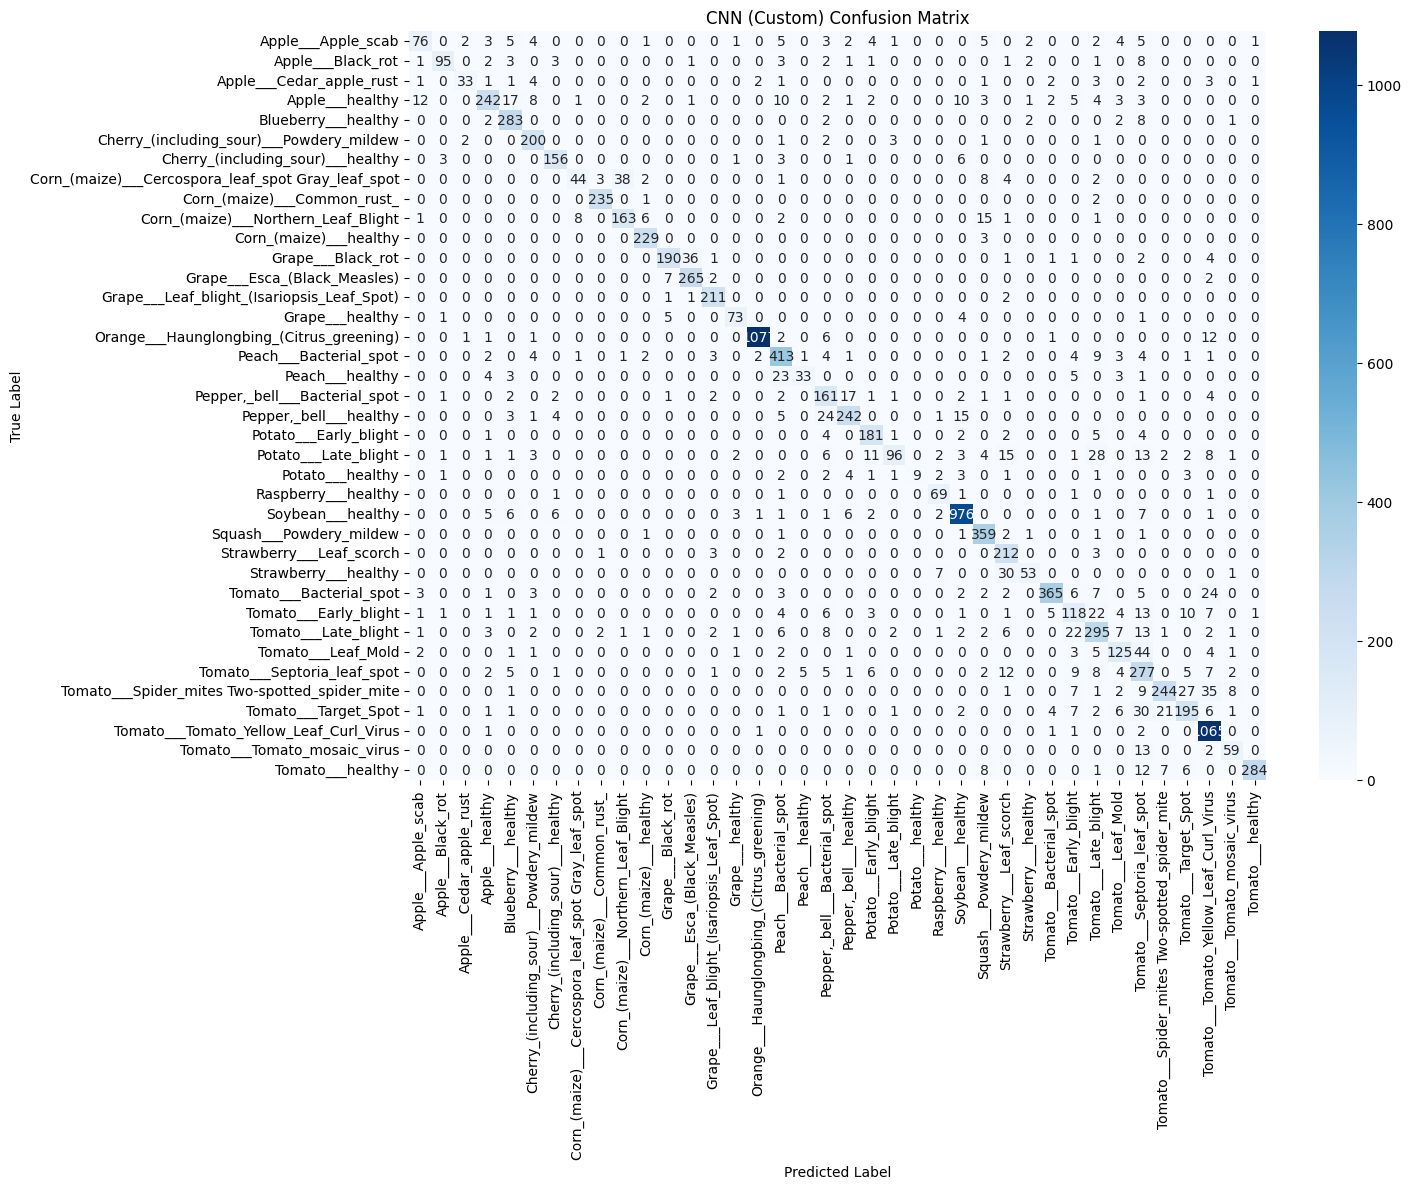

Saved ROC curve to: cnn_roc_curve.png


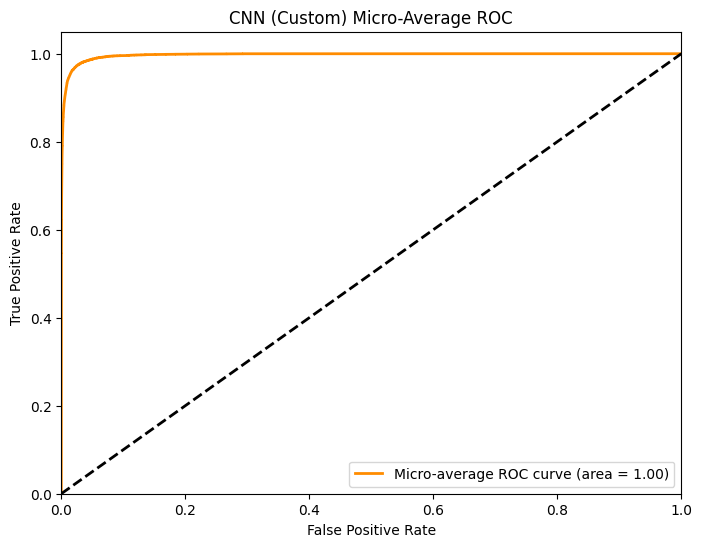


--- Generating VGG16 Plots ---
Saved confusion matrix to: vgg16_confusion_matrix.png


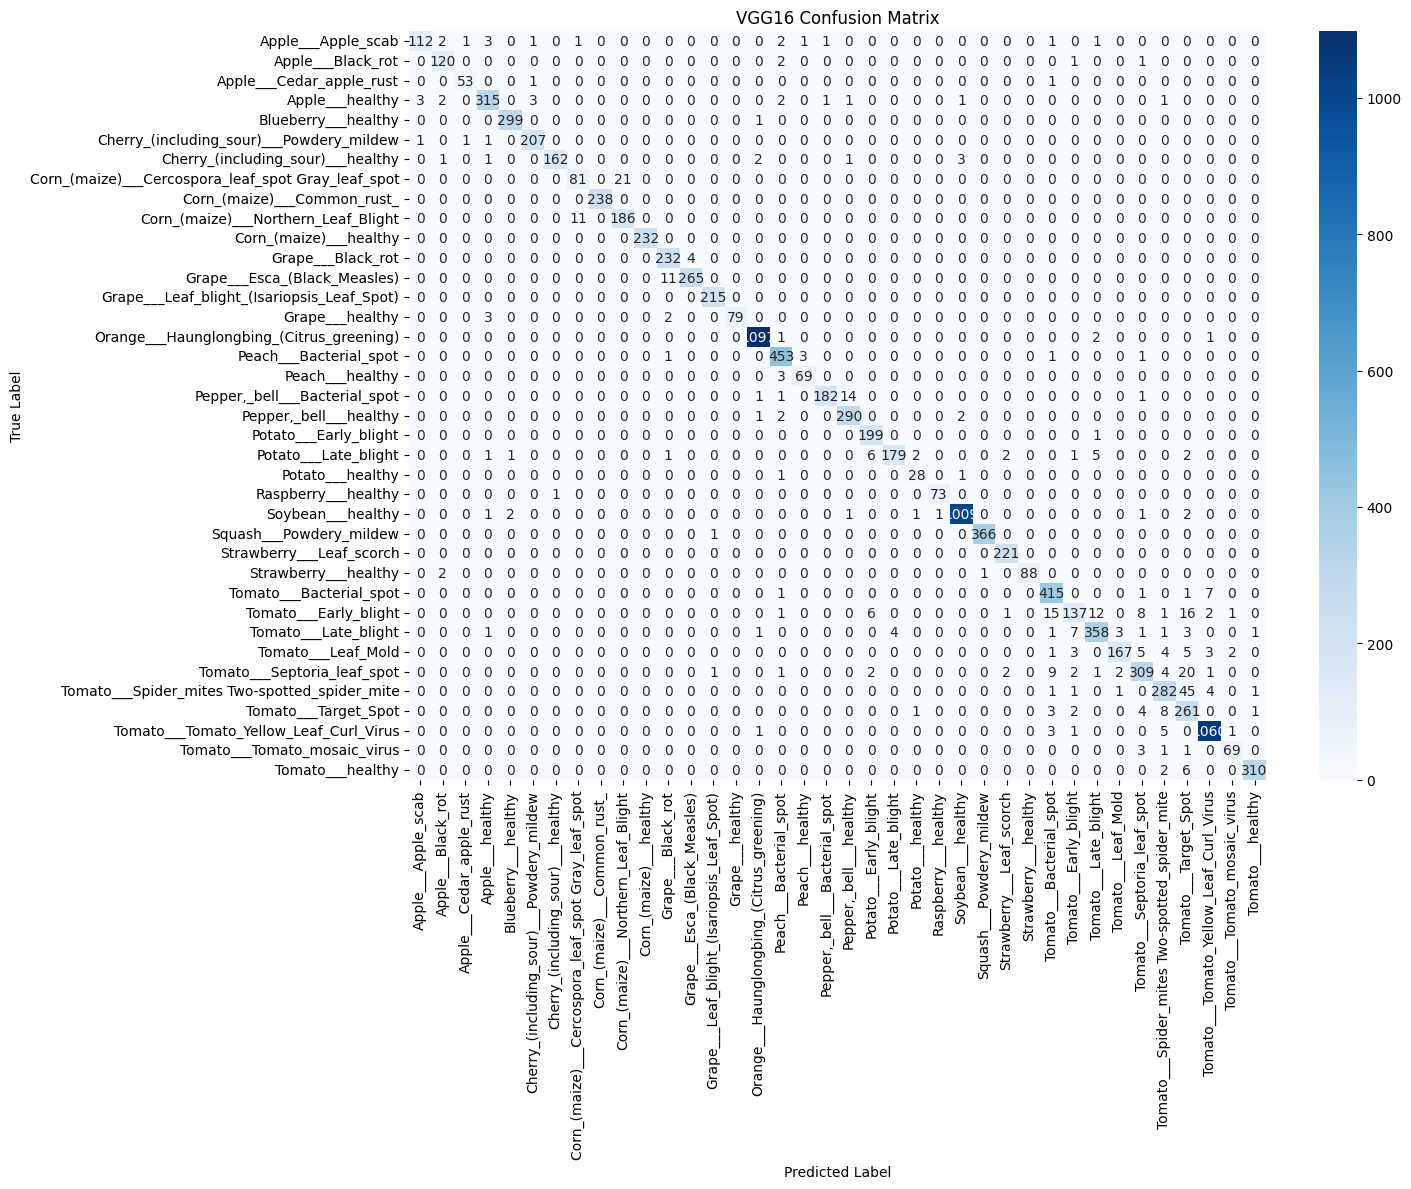

Saved ROC curve to: vgg16_roc_curve.png


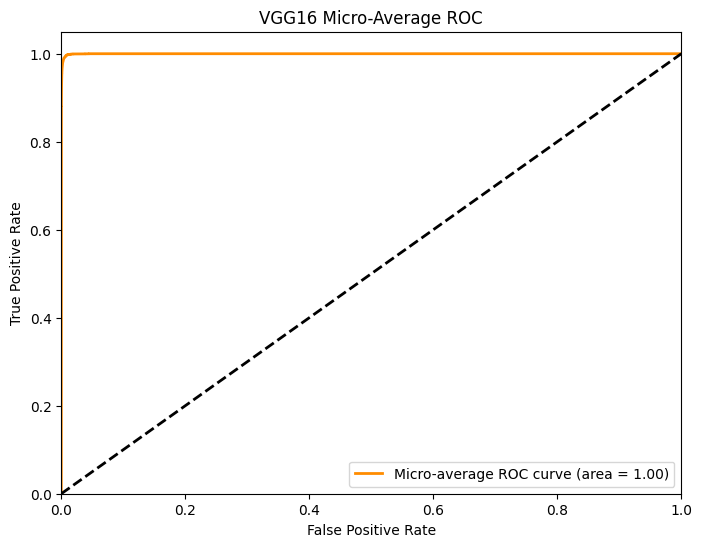

In [ ]:
def plot_confusion_matrix(cm, class_names, title='Confusion Matrix', filename='confusion_matrix.png'):
    plt.figure(figsize=(15, 12))
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()  # Adjust layout to prevent labels from being cut off
    plt.savefig(filename) # Save the plot as an image
    print(f"Saved confusion matrix to: {filename}")
    plt.show()

# Helper function to plot AUC-ROC Curve (Micro-average)
def plot_roc_curve(y_true_one_hot, y_pred_probs, title='ROC Curve', filename='roc_curve.png'):
    # Calculate micro-average ROC curve and ROC area
    fpr, tpr, _ = roc_curve(y_true_one_hot.ravel(), y_pred_probs.ravel())
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2,
             label=f'Micro-average ROC curve (area = {roc_auc:0.2f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc="lower right")
    plt.savefig(filename) # Save the plot as an image
    print(f"Saved ROC curve to: {filename}")
    plt.show()

#1. Plotting for the CNN (Custom) model
print("--- Generating CNN (Custom) Plots ---")
try:
    cm_cnn = confusion_matrix(y_true_cnn, y_pred_cnn)
    plot_confusion_matrix(cm_cnn, class_labels,
                          title='CNN (Custom) Confusion Matrix',
                          filename='cnn_confusion_matrix.png')

    plot_roc_curve(y_true_cnn_oh, Y_pred_cnn,
                   title='CNN (Custom) Micro-Average ROC',
                   filename='cnn_roc_curve.png')
except NameError:
    print("Error: Could not find 'y_true_cnn' or 'Y_pred_cnn'. Please re-run Step 2.")

# 2. Plotting for the VGG16 model 
print("\n--- Generating VGG16 Plots ---")
try:
    cm_vgg = confusion_matrix(y_true_vgg, y_pred_vgg)
    plot_confusion_matrix(cm_vgg, class_labels,
                          title='VGG16 Confusion Matrix',
                          filename='vgg16_confusion_matrix.png')

    plot_roc_curve(y_true_vgg_oh, Y_pred_vgg,
                   title='VGG16 Micro-Average ROC',
                   filename='vgg16_roc_curve.png')
except NameError:
    print("Error: Could not find 'y_true_vgg' or 'Y_pred_vgg'. Please re-run Step 2.")
